<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

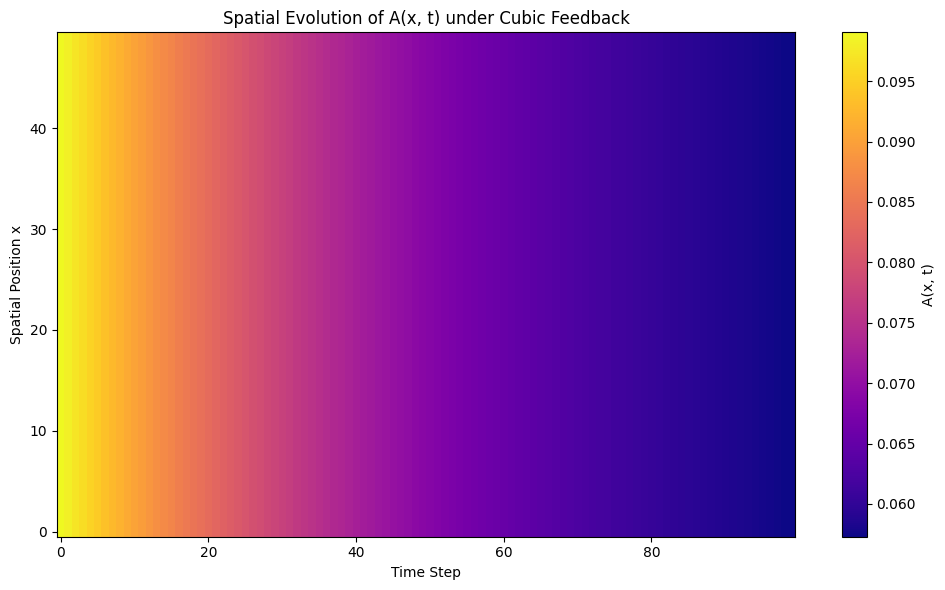

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
kappa = 0.2
delta = 0.02
gamma0 = 0.5
xi = 0.01
A0 = 0.1
time_steps = 100
grid_size = 50
epsilon = 0.2  # Stronger cubic feedback

# -------------------------------
# Initialize Field and History
# -------------------------------
A = np.ones(grid_size) * A0
field_history = []

# -------------------------------
# Evolution Loop
# -------------------------------
for t in range(time_steps):
    laplacian = np.roll(A, -1) - 2 * A + np.roll(A, 1)
    dA_dt = -kappa * A + delta * A**2 + epsilon * A**3 + gamma0 * laplacian + xi
    A += dA_dt * 0.1
    field_history.append(A.copy())

# -------------------------------
# Convert to Array for Plotting
# -------------------------------
field_array = np.array(field_history)

# -------------------------------
# Plot Heatmap of A(x, t)
# -------------------------------
plt.figure(figsize=(10, 6))
plt.imshow(field_array.T, aspect='auto', cmap='plasma', origin='lower')
plt.title("Spatial Evolution of A(x, t) under Cubic Feedback")
plt.xlabel("Time Step")
plt.ylabel("Spatial Position x")
plt.colorbar(label="A(x, t)")
plt.tight_layout()
plt.show()
